$T_0$ berechnen

In [1]:
import numpy as np
import uncertainties as unc
import uncertainties.unumpy as unp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [2]:
T = np.array([39.61, 39.72, 39.73])

unc_T = 0.25

T = unp.uarray(T, unc_T)
T_0 = T/20
T_0
T_fin_err = np.sqrt((np.std(unp.nominal_values(T_0), ddof=1) / np.sqrt(len(T_0)))**2 + 0.013**2)
T_fin = unc.ufloat(
    float(np.mean(unp.nominal_values(T_0))),
    float(T_fin_err)
)
print(T_fin)
print(1/T_fin)





1.984+/-0.013
0.5039+/-0.0033


In [3]:

i1_run1 = [20.0, 16.5, 13.6, 11.2, 9.2, 7.6, 6.2, 5.0, 4.0, 3.2, 2.6, 2.1, 1.7, 1.3, 1.0, 0.8, 0.6, 0.5]
i1_run2 = [20.0, 16.2, 13.5, 11.1, 9.0, 7.4, 6.0, 5.0, 4.0, 3.2, 2.6, 2.0, 1.6, 1.3, 1.0, 0.8, 0.6, 0.4]

i2_run1 = [20.0, 14.6, 10.7, 7.8, 5.6, 4.1, 2.9, 2.0, 1.4, 1.0, 0.7, 0.5, 0.3]
i2_run2 = [20.0, 14.8, 10.7, 7.8, 5.6, 4.1, 2.9, 2.0, 1.4, 1.0, 0.6, 0.2]

def calculate_averages(run1, run2, n_max):
    averages = []
    for i in range(n_max):
        values = []
        if i < len(run1): values.append(run1[i])
        if i < len(run2): values.append(run2[i])
        
        if values:
            avg = sum(values) / len(values)
            averages.append(avg)
        else:
            averages.append(None)
    return averages



# Process averages
i1_avg = calculate_averages(i1_run1, i1_run2, len(i1_run1))
i2_avg = calculate_averages(i2_run1, i2_run2,  len(i2_run1))


#print("Averages for Damping Current 1:", i1_avg)
#print("Averages for Damping Current 2:", i2_avg)
#

Fitted parameters for Damping Current 1: a = 20.141418645517, b = -0.2019534759495409
Fitted parameters for Damping Current 2: a = 20.14544028297295, b = -0.3215491353551395


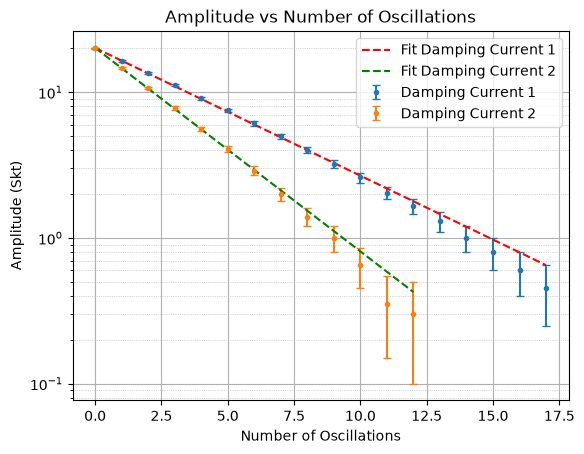

In [4]:
plt.errorbar(range(len(i1_avg)), i1_avg, yerr=0.2, fmt='.', label='Damping Current 1', capsize=3)
plt.errorbar(range(len(i2_avg)), i2_avg, yerr=0.2, fmt='.', label='Damping Current 2', capsize=3)
plt.xlabel('Number of Oscillations')
plt.ylabel('Amplitude (Skt)')
plt.title('Amplitude vs Number of Oscillations')
plt.legend()
plt.yscale('log')
plt.grid()
plt.grid(which='minor', linestyle=':', linewidth=0.5)

popt1, pcov1 = curve_fit(lambda x, a, b: a * np.exp(b * x), range(len(i1_avg)), i1_avg, p0=(20, -0.2))
popt2, pcov2 = curve_fit(lambda x, a, b: a * np.exp(b * x), range(len(i2_avg)), i2_avg, p0=(20, -0.2))

print(f"Fitted parameters for Damping Current 1: a = {popt1[0]}, b = {popt1[1]}")
print(f"Fitted parameters for Damping Current 2: a = {popt2[0]}, b = {popt2[1]}")

plt.plot(range(len(i1_avg)), popt1[0] * np.exp(popt1[1] * np.array(range(len(i1_avg)))), 'r--', label='Fit Damping Current 1')
plt.plot(range(len(i2_avg)), popt2[0] * np.exp(popt2[1] * np.array(range(len(i2_avg)))), 'g--', label='Fit Damping Current 2')
plt.legend()



In [5]:
d1 = unc.ufloat(-0.21, 0.05)
d2 = unc.ufloat(-0.35, 0.05)

delta_280 = d1/T_fin
delta_360 = d2/T_fin
print(f"Damping constant for 280 mA: {delta_280}")
print(f"Damping constant for 360 mA: {delta_360}")
print(f"Fitted by python: Damping constant for 280 mA (exponential): {popt1[1]/T_fin}")
print(f"Fitted by python: Damping constant for 360 mA (exponential): {popt2[1]/T_fin}")


Damping constant for 280 mA: -0.106+/-0.025
Damping constant for 360 mA: -0.176+/-0.025
Fitted by python: Damping constant for 280 mA (exponential): -0.1018+/-0.0007
Fitted by python: Damping constant for 360 mA (exponential): -0.1620+/-0.0011


Excercise 3

In [6]:
f = np.array([300, 500, 700, 900, 1100, 1300, 1500, 1600, 1700, 1800, 1850, 1900, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100, 2150, 2200, 2250, 2300, 2500, 2700, 2900, 3100]) / 4000

b_I1 = np.array([0.4, 0.4, 0.4, 0.5, 0.55, 0.7, 0.9, 1.0, 1.3, 1.8, 2.2, 2.8, 3.8, 4.3, 4.6, 4.9, 5.3, 5.7, 5.9, 6.1, 6.1, 6.0, 5.7, 5.2, 4.8, 4.5, 4.2, 3.8, 2.6, 2.0, 1.6, 1.3, 0.8, 0.6, 0.4, 0.3])

b_I2 = np.array([0.4, 0.5, 0.5, 0.5, 0.6, 0.7, 0.8, 1.0, 1.3, 1.7, 2.0, 2.5, 3.1, 3.2, 3.3, 3.4, 3.6, 3.7, 3.8, 3.8, 3.7, 3.7, 3.6, 3.5, 3.4, 3.2, 3.0, 2.9, 2.3, 1.8, 1.5, 1.3, 0.7, 0.6, 0.4, 0.4])

err = 0.2
omega = 2 * np.pi * f


def amplitude_curve(omega, A_0, omega_0, gamma):
    return A_0 * omega_0**2 / np.sqrt((omega_0**2 - omega**2)**2 + (2 * gamma * omega)**2)


fit_results = {}
for label, amplitudes in {"I1": b_I1, "I2": b_I2}.items():
    initial_guess = (0.2, omega[np.argmax(amplitudes)], 0.05)
    parameters, covariance = curve_fit(
        amplitude_curve,
        omega,
        amplitudes,
        p0=initial_guess,
        sigma=np.full_like(omega, err),
        absolute_sigma=True,
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
        x_scale="jac",
        maxfev=10000,
    )
    
    A_0, omega_0, gamma = parameters
    fit_results[label] = (parameters, covariance)
    print(f"{label}: A_0 = {A_0:.6f}, omega_0 = {omega_0:.6f}")
    print(f"{label}: gamma = {gamma:.6f}")
    print(f"{label}: gamma = {gamma * 4000:.3f} rad/s = {gamma * 4000 / (2 * np.pi):.3f} Hz")
    print(f"{label}: FWHM = {2 * gamma * 4000 / (2 * np.pi):.3f} Hz")

I1: A_0 = 0.374702, omega_0 = 3.183433
I1: gamma = 0.098050
I1: gamma = 392.200 rad/s = 62.421 Hz
I1: FWHM = 124.841 Hz
I2: A_0 = 0.386554, omega_0 = 3.182402
I2: gamma = 0.165132
I2: gamma = 660.529 rad/s = 105.126 Hz
I2: FWHM = 210.253 Hz


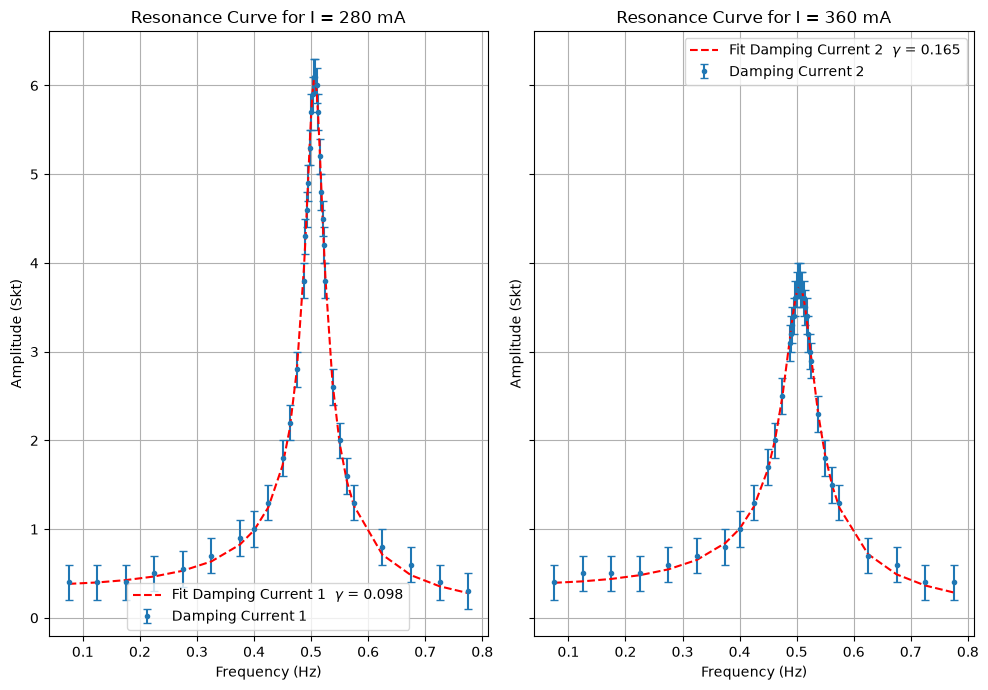

In [22]:
fig, (ax1, ax2) = plt.subplots(figsize=(10, 7), ncols=2, sharex=True, sharey=True)

ax1.errorbar(f, b_I1, yerr=err, fmt='.', label='Damping Current 1', capsize=3)
ax2.errorbar(f, b_I2, yerr=err, fmt='.', label='Damping Current 2', capsize=3)
ax1.grid()
ax2.grid()

ax1.plot(
    f,
    amplitude_curve(2 * np.pi * f, *fit_results["I1"][0]),
    "r--",
    label=rf"Fit Damping Current 1  $\gamma$ = {fit_results['I1'][0][2]:.3f}",
)
ax2.plot(
    f,
    amplitude_curve(2 * np.pi * f, *fit_results["I2"][0]),
    "r--",
    label=rf"Fit Damping Current 2  $\gamma$ = {fit_results['I2'][0][2]:.3f}",
)


ax1.set_ylabel("Amplitude (Skt)")
ax2.set_ylabel("Amplitude (Skt)")
ax1.set_xlabel("Frequency (Hz)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_title("Resonance Curve for I = 360 mA")
ax1.set_title("Resonance Curve for I = 280 mA")
ax1.legend()
ax2.legend()
plt.tight_layout()

In [8]:
w_0_280 = unc.ufloat(0.505, 0.005) * 2 * 3.141
w_0_360 = unc.ufloat(0.506, 0.005) * 2 * 3.141


Q_280 = w_0_280 /( delta_280 * 2)
Q_360 = w_0_360 /( delta_360 * 2)
print(f"Quality factor for 280 mA: {Q_280:.3uP}")
print(f"Quality factor for 360 mA: {Q_360:.3uP}")

Quality factor for 280 mA: -14.99±3.57
Quality factor for 360 mA: -9.01±1.29


In [9]:
win_280 = unc.ufloat(0.4, 0.2)
win_360 = unc.ufloat(0.4, 0.2)

wmax_280 = unc.ufloat(6.1, 0.2)
wmax_360 = unc.ufloat(3.8, 0.2)

print(f"Quality factor for 280 mA (measured): {wmax_280/win_280:.3uP}")
print(f"Quality factor for 360 mA (measured): {wmax_360/win_360:.3uP}")

Quality factor for 280 mA (measured): 15.25±7.64
Quality factor for 360 mA (measured): 9.50±4.78


In [10]:
print(delta_280.s)
sigma_err_delta_280 = (-delta_280.n - 0.110)/np.sqrt(delta_280.s**2 + 0.016**2)
sigma_err_delta_360 = (-delta_360.n - 0.141)/np.sqrt(delta_360.s**2 + 0.016**2)

print(f"Sigma error for delta_280: {sigma_err_delta_280:.3f}")
print(f"Sigma error for delta_360: {sigma_err_delta_360:.3f}")

0.02520712463532635
Sigma error for delta_280: -0.140
Sigma error for delta_360: 1.184
